In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [5]:
#Getting image
img = Image.open("BW1.jpg")

# Greyscale conversion
imgGray = img.convert("L")

#Making the array
imgArr =np.array(imgGray,dtype=float)

print("Image dimensions are : ",imgArr.shape)

Image dimensions are :  (4000, 6000)


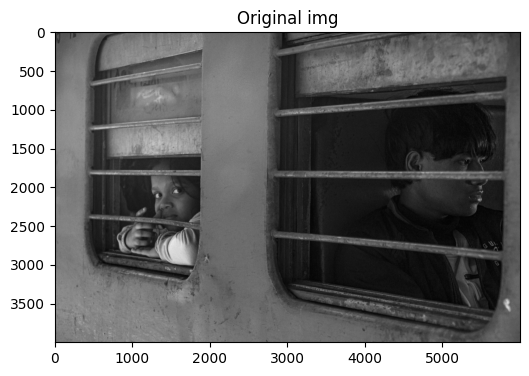

In [6]:
#original img
plt.figure(figsize=(6,6))
plt.title("Original img")
plt.imshow(imgArr, cmap='grey')


plt.show()

img = Image.fromarray(imgArr.astype('uint8'))
img.show()

In [7]:
#mean of every column
meanC = np.mean(imgArr, axis=0)
imgCen = imgArr-meanC #Centering


# Covariance matrix
Cov = (imgCen.T @ imgCen) / (imgCen.shape[0]-1)  #Bessel correction

In [8]:
eigVals, eigVecs=np.linalg.eigh(Cov) #eigen decomp.

#descending eigenvalues (gives indexes)
idx = np.argsort(eigVals)[::-1] 

eigVals = eigVals[idx]
eigVecs= eigVecs[:,idx]  #resorting vectors  


scores = imgCen@eigVecs

In [9]:
#Reconstruct image using top k principal components
def reconstruct_pca(scores, eigVecs, meanC, k):

    vK = eigVecs[:, :k]
    scoresK = scores[:, :k]

    aK = scoresK @ vK.T + meanC

    return np.clip(aK, 0, 255)

In [10]:
#kVal= [5, 50, 200]

# Show original image
#Image.fromarray(imgArr.astype('uint8')).show()

# Show PCA reconstructions
#for k in kVal:

#    recon = reconstruct_pca(scores, eigVecs, meanC, k)

#    img = Image.fromarray(recon.astype('uint8'))
#    img.show()

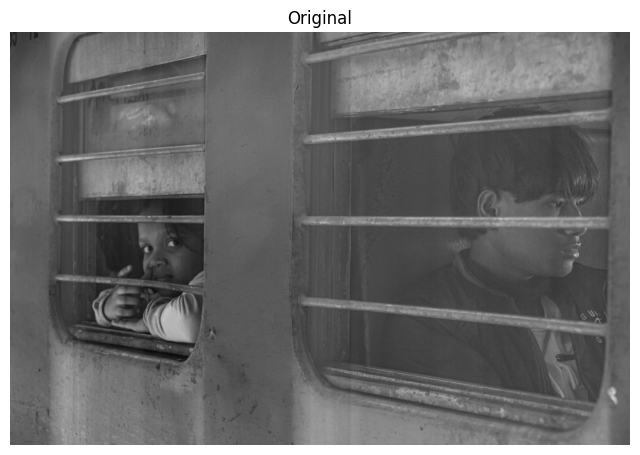

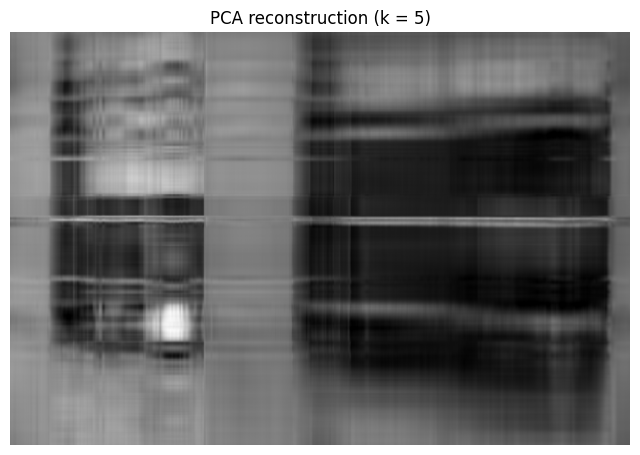

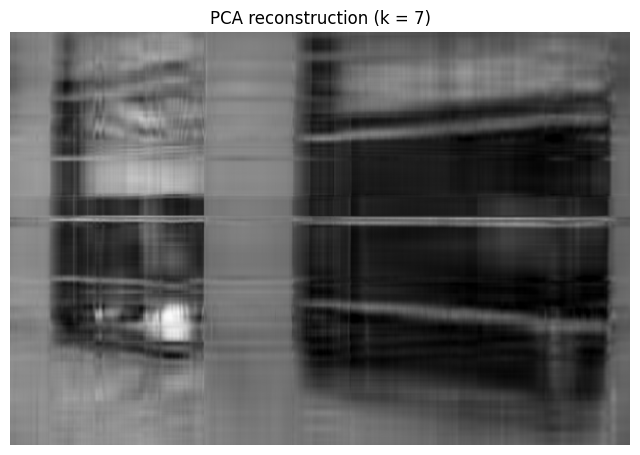

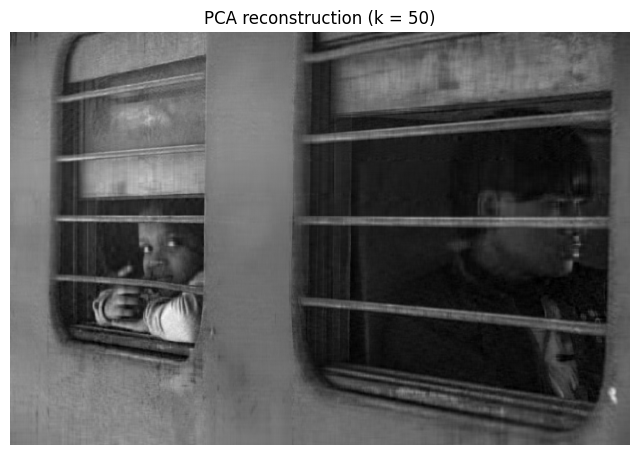

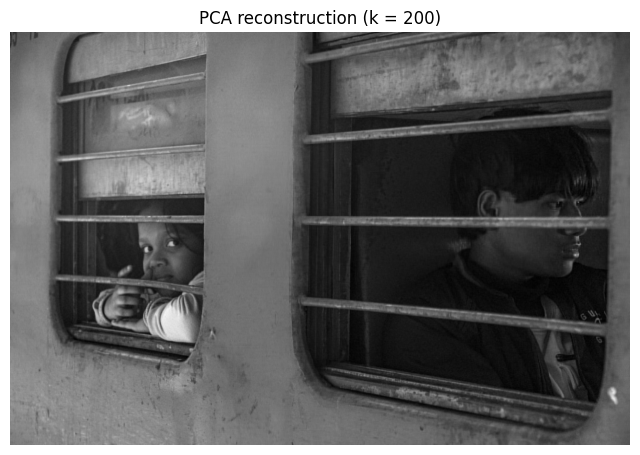

In [11]:
kVal = [5, 7, 50, 200]

plt.figure(figsize=(8,8))
plt.imshow(imgCen, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.show()

# show PCA reconstructions
for k in kVal:

    recon = reconstruct_pca(scores, eigVecs, meanC, k)

    plt.figure(figsize=(8,8))
    plt.imshow(recon, cmap='gray')
    plt.title(f"PCA reconstruction (k = {k})")
    plt.axis("off")
    plt.show()